# GraphX — Phân tích mạng lưới giao dịch
Phát hiện gian lận thẻ tín dụng với GraphFrames

---

In [18]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("FraudDetection_GraphX") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
spark.sparkContext.setCheckpointDir("/tmp/graphframes_checkpoint")

from graphframes import GraphFrame

## Chuẩn bị dữ liệu Graph

In [19]:
train_df = spark.read.csv("data/fraudTrain.csv", header=True, inferSchema=True)
test_df = spark.read.csv("data/fraudTest.csv", header=True, inferSchema=True)

train_graph = train_df.select(
    F.sha2(F.col("cc_num").cast("string"), 256).alias("customer_id"),
    "merchant", "amt", "is_fraud"
)
test_graph = test_df.select(
    F.sha2(F.col("cc_num").cast("string"), 256).alias("customer_id"),
    "merchant", "amt", "is_fraud"
)

graph_data = train_graph.union(test_graph)
print(f"Tong giao dich: {graph_data.count():,}")
print(f"Fraud: {graph_data.filter(F.col('is_fraud') == 1).count():,}")
graph_data.show(5, truncate=20)

Tong giao dich: 1,852,394
Fraud: 9,651
+--------------------+--------------------+------+--------+
|         customer_id|            merchant|   amt|is_fraud|
+--------------------+--------------------+------+--------+
|80923ef01336409c8...|fraud_Rippin, Kub...|  4.97|       0|
|f80a8e60a9f15ecf1...|fraud_Heller, Gut...|107.23|       0|
|756a303c0348d0ebb...|fraud_Lind-Buckridge|220.11|       0|
|374dcb008121abf2b...|fraud_Kutch, Herm...|  45.0|       0|
|7f921c03617da9920...| fraud_Keeling-Crist| 41.96|       0|
+--------------------+--------------------+------+--------+
only showing top 5 rows


In [20]:
customers = graph_data.select(
    F.col("customer_id").alias("id")
).distinct().withColumn("type", F.lit("customer"))

merchants = graph_data.select(
    F.col("merchant").alias("id")
).distinct().withColumn("type", F.lit("merchant"))

vertices = customers.union(merchants)

edges = graph_data.select(
    F.col("customer_id").alias("src"),
    F.col("merchant").alias("dst"),
    "amt", "is_fraud"
)

print(f"Vertices: {vertices.count():,} (Customer: {customers.count():,}, Merchant: {merchants.count():,})")
print(f"Edges: {edges.count():,}")

g = GraphFrame(vertices, edges)

Vertices: 1,692 (Customer: 999, Merchant: 693)
Edges: 1,852,394


---
## Degree Analysis

In [21]:
in_deg = g.inDegrees
merchant_deg = in_deg.join(vertices, "id").filter(F.col("type") == "merchant")

print("Top 15 merchant co nhieu giao dich nhat:")
merchant_deg.orderBy(F.desc("inDegree")).show(15, truncate=30)

out_deg = g.outDegrees
customer_deg = out_deg.join(vertices, "id").filter(F.col("type") == "customer")

print(f"Customer degree — min: {customer_deg.agg(F.min('outDegree')).first()[0]}, "
      f"max: {customer_deg.agg(F.max('outDegree')).first()[0]}, "
      f"avg: {customer_deg.agg(F.avg('outDegree')).first()[0]:.1f}")

Top 15 merchant co nhieu giao dich nhat:


+------------------------------+--------+--------+
|                            id|inDegree|    type|
+------------------------------+--------+--------+
|             fraud_Kilback LLC|    6262|merchant|
|             fraud_Cormier LLC|    5246|merchant|
|              fraud_Schumm PLC|    5195|merchant|
|                fraud_Kuhn LLC|    5031|merchant|
|               fraud_Boyer PLC|    4999|merchant|
|           fraud_Dickinson Ltd|    4953|merchant|
|               fraud_Emard Inc|    3867|merchant|
|         fraud_Cummerata-Jones|    3860|merchant|
|          fraud_Corwin-Collins|    3853|merchant|
|         fraud_Rodriguez Group|    3843|merchant|
|               fraud_Kling Inc|    3841|merchant|
|       fraud_Parisian and Sons|    3839|merchant|
|        fraud_Erdman-Kertzmann|    3839|merchant|
|              fraud_Huels-Hahn|    3835|merchant|
|fraud_Stroman, Hudson and E...|    3829|merchant|
+------------------------------+--------+--------+
only showing top 15 rows


Customer degree — min: 6, max: 4392, avg: 1854.2


In [22]:
fraud_edges = edges.filter(F.col("is_fraud") == 1)
normal_edges = edges.filter(F.col("is_fraud") == 0)

merchant_fraud = fraud_edges.groupBy("dst").agg(
    F.count("*").alias("fraud_count"),
    F.sum("amt").alias("fraud_amt")
)
merchant_normal = normal_edges.groupBy("dst").agg(
    F.count("*").alias("normal_count")
)
merchant_stats = merchant_fraud.join(merchant_normal, merchant_fraud["dst"] == merchant_normal["dst"], "left") \
    .select(merchant_fraud["dst"].alias("merchant"), "fraud_count", "fraud_amt", "normal_count") \
    .withColumn("fraud_rate", F.col("fraud_count") / (F.col("fraud_count") + F.coalesce(F.col("normal_count"), F.lit(0))))

print("Top 15 merchant co nhieu giao dich fraud nhat:")
merchant_stats.orderBy(F.desc("fraud_count")).show(15, truncate=30)

Top 15 merchant co nhieu giao dich fraud nhat:


+------------------------------+-----------+------------------+------------+--------------------+
|                      merchant|fraud_count|         fraud_amt|normal_count|          fraud_rate|
+------------------------------+-----------+------------------+------------+--------------------+
|             fraud_Kilback LLC|         62|17253.350000000006|        6200|0.009900990099009901|
|            fraud_Rau and Sons|         60|          18810.28|        3486| 0.01692047377326565|
|             fraud_Kozey-Boehm|         60|60410.619999999995|        2698|0.021754894851341553|
|               fraud_Doyle Ltd|         57|          17854.06|        3445|0.016276413478012564|
|              fraud_Terry-Huel|         56|          55203.84|        2808|0.019553072625698324|
|               fraud_Boyer PLC|         55| 51363.52999999999|        4944|0.011002200440088018|
|                fraud_Kuhn LLC|         55|          45997.56|        4976|0.010932220234545816|
|fraud_Mosciski, Zie

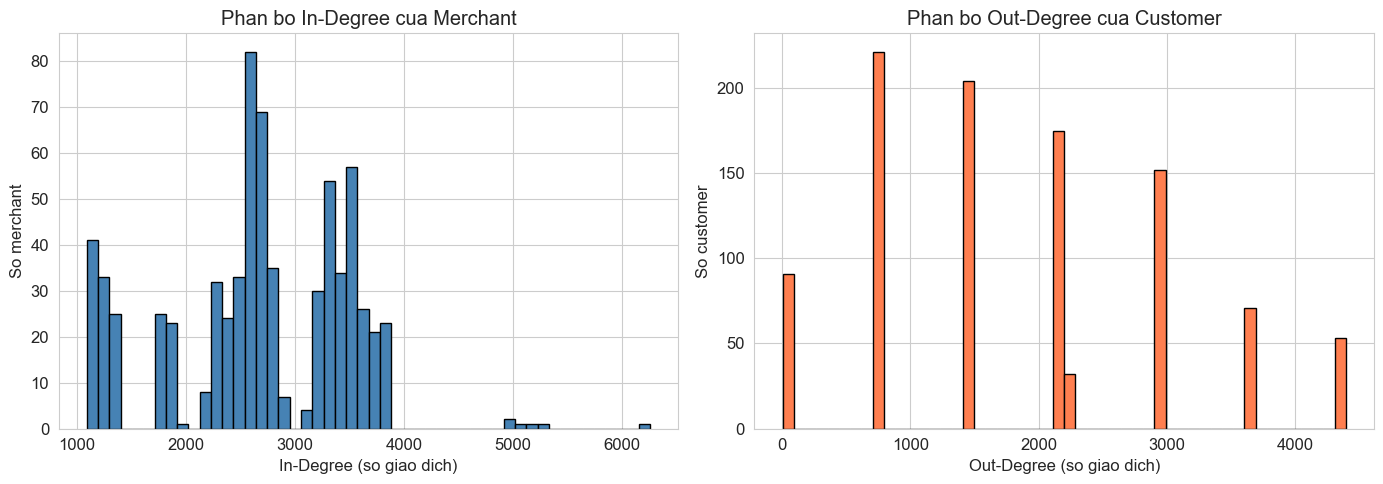

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

merchant_deg_pd = merchant_deg.select("inDegree").toPandas()
axes[0].hist(merchant_deg_pd["inDegree"], bins=50, color="steelblue", edgecolor="black")
axes[0].set_xlabel("In-Degree (so giao dich)")
axes[0].set_ylabel("So merchant")
axes[0].set_title("Phan bo In-Degree cua Merchant")

customer_deg_pd = customer_deg.select("outDegree").toPandas()
axes[1].hist(customer_deg_pd["outDegree"], bins=50, color="coral", edgecolor="black")
axes[1].set_xlabel("Out-Degree (so giao dich)")
axes[1].set_ylabel("So customer")
axes[1].set_title("Phan bo Out-Degree cua Customer")

plt.tight_layout()
plt.show()

---
## PageRank

In [24]:
pr = g.pageRank(resetProbability=0.15, maxIter=10)

pr_vertices = pr.vertices
pr_merchants = pr_vertices.filter(F.col("type") == "merchant")
pr_customers = pr_vertices.filter(F.col("type") == "customer")

print("Top 15 merchant PageRank cao nhat:")
pr_merchants.orderBy(F.desc("pagerank")).select("id", "pagerank").show(15, truncate=30)

print("Top 15 customer PageRank cao nhat:")
pr_customers.orderBy(F.desc("pagerank")).select("id", "pagerank").show(15, truncate=20)

Top 15 merchant PageRank cao nhat:
+------------------------------+------------------+
|                            id|          pagerank|
+------------------------------+------------------+
|             fraud_Cormier LLC|2.8222964879031305|
|             fraud_Kilback LLC|2.5889938607263403|
|                fraud_Kuhn LLC| 2.550877569262537|
|               fraud_Boyer PLC|  2.42889601890413|
|              fraud_Schumm PLC|2.3698293072556686|
|         fraud_Heidenreich PLC| 2.142916470040036|
|               fraud_Doyle Ltd|2.1413118491871543|
|        fraud_Goodwin-Nitzsche| 2.109936911038984|
|fraud_Schumm, Bauch and Ond...|2.1085710649172564|
|            fraud_Koepp-Parker|2.1006466249132645|
|          fraud_Kiehn-Emmerich|2.0933816464151738|
|           fraud_Dickinson Ltd|2.0874424133322957|
|fraud_Schultz, Simonis and ...|2.0762015957727282|
|         fraud_Prohaska-Murray| 2.071303337609452|
|               fraud_Kunze Inc|2.0575837906851917|
+----------------------------

In [25]:
merchant_pr_fraud = pr_merchants.join(merchant_stats, pr_merchants["id"] == merchant_stats["merchant"], "left")

fraud_merchants = merchant_pr_fraud.filter(F.col("fraud_count").isNotNull())
clean_merchants = merchant_pr_fraud.filter(F.col("fraud_count").isNull())

avg_pr_fraud = fraud_merchants.agg(F.avg("pagerank")).first()[0]
avg_pr_clean = clean_merchants.agg(F.avg("pagerank")).first()[0]

print(f"PageRank trung binh:")
print(f"  Merchant co fraud:    {avg_pr_fraud:.6f}")
print(f"  Merchant khong fraud: {avg_pr_clean:.6f}" if avg_pr_clean else "  Merchant khong fraud: N/A")

PageRank trung binh:
  Merchant co fraud:    1.485323
  Merchant khong fraud: 1.172380


---
## Connected Components

In [26]:
cc = g.connectedComponents()

comp_sizes = cc.groupBy("component").agg(
    F.count("*").alias("size"),
    F.sum(F.when(F.col("type") == "customer", 1).otherwise(0)).alias("n_customers"),
    F.sum(F.when(F.col("type") == "merchant", 1).otherwise(0)).alias("n_merchants")
).orderBy(F.desc("size"))

print(f"So connected components: {comp_sizes.count()}")
print("\nTop 10 component lon nhat:")
comp_sizes.show(10)

So connected components: 1

Top 10 component lon nhat:
+---------+----+-----------+-----------+
|component|size|n_customers|n_merchants|
+---------+----+-----------+-----------+
|        0|1692|        999|        693|
+---------+----+-----------+-----------+



In [27]:
cc_with_edges = cc.join(edges, cc["id"] == edges["src"], "inner")
comp_fraud = cc_with_edges.groupBy("component").agg(
    F.count("*").alias("total_txn"),
    F.sum("is_fraud").alias("fraud_count")
).withColumn("fraud_rate", F.col("fraud_count") / F.col("total_txn"))

print("Ty le fraud theo component:")
comp_fraud.filter(F.col("total_txn") >= 100) \
    .orderBy(F.desc("fraud_rate")).show(10)

Ty le fraud theo component:


+---------+---------+-----------+--------------------+
|component|total_txn|fraud_count|          fraud_rate|
+---------+---------+-----------+--------------------+
|        0|  1852394|       9651|0.005210014716091717|
+---------+---------+-----------+--------------------+



---
## Fraud Subgraph

In [28]:
fraud_edges_only = edges.filter(F.col("is_fraud") == 1)

fraud_nodes = fraud_edges_only.select(F.col("src").alias("id")).union(
    fraud_edges_only.select(F.col("dst").alias("id"))
).distinct()
fraud_vertices = vertices.join(fraud_nodes, "id", "inner")

fraud_graph = GraphFrame(fraud_vertices, fraud_edges_only)

n_fraud_customers = fraud_vertices.filter(F.col("type") == "customer").count()
n_fraud_merchants = fraud_vertices.filter(F.col("type") == "merchant").count()

print(f"Fraud subgraph: {fraud_vertices.count():,} vertices (customer: {n_fraud_customers:,}, merchant: {n_fraud_merchants:,}), {fraud_edges_only.count():,} edges")

print("\nTop 15 merchant fraud:")
fraud_edges_only.groupBy("dst").agg(
    F.count("*").alias("fraud_txn"),
    F.sum("amt").alias("total_fraud_amt"),
    F.countDistinct("src").alias("unique_victims")
).orderBy(F.desc("fraud_txn")).show(15, truncate=30)

Fraud subgraph: 1,661 vertices (customer: 976, merchant: 685), 9,651 edges

Top 15 merchant fraud:
+------------------------------+---------+------------------+--------------+
|                           dst|fraud_txn|   total_fraud_amt|unique_victims|
+------------------------------+---------+------------------+--------------+
|             fraud_Kilback LLC|       62|17253.350000000006|            60|
|            fraud_Rau and Sons|       60|18810.280000000002|            58|
|             fraud_Kozey-Boehm|       60|          60410.62|            58|
|               fraud_Doyle Ltd|       57|17854.059999999998|            57|
|              fraud_Terry-Huel|       56| 55203.84000000001|            54|
|               fraud_Boyer PLC|       55|          51363.53|            55|
|                fraud_Kuhn LLC|       55| 45997.55999999998|            52|
|          fraud_Kiehn-Emmerich|       53|16669.099999999995|            52|
|             fraud_Cormier LLC|       53|          49

---
## Triangle Count (Merchant-Merchant Projection)
Do đồ thị gốc là **bipartite** (customer ↔ merchant), không thể có triangle trực tiếp.  
→ Chiếu sang đồ thị **merchant–merchant**: hai merchant nối nhau nếu có chung customer bị fraud.  
→ Triangle = 3 merchant cùng bị nhóm fraudster chung nhắm vào.

In [29]:
# --- Chieu (project) sang merchant-merchant graph ---
# Hai merchant duoc noi voi nhau neu co chung customer bi fraud
fraud_pairs = fraud_edges_only.select(
    F.col("src").alias("customer"),
    F.col("dst").alias("merchant")
).distinct()

# Self-join: tim cac cap merchant co chung customer fraud
merchant_merchant = fraud_pairs.alias("a").join(
    fraud_pairs.alias("b"),
    (F.col("a.customer") == F.col("b.customer")) & (F.col("a.merchant") < F.col("b.merchant"))
).select(
    F.col("a.merchant").alias("m1"),
    F.col("b.merchant").alias("m2"),
    F.col("a.customer").alias("shared_customer")
)

# Dem so customer chung giua moi cap merchant
merchant_edges = merchant_merchant.groupBy("m1", "m2").agg(
    F.count("*").alias("shared_fraud_customers")
)

print(f"So cap merchant co chung customer fraud: {merchant_edges.count():,}")
print("\nTop 15 cap merchant co nhieu customer fraud chung nhat:")
merchant_edges.orderBy(F.desc("shared_fraud_customers")).show(15, truncate=25)

# Tao graph merchant-merchant va dem triangle
m_vertices = merchants.select(F.col("id"))
m_edges_directed = merchant_edges.select(
    F.col("m1").alias("src"), F.col("m2").alias("dst"), "shared_fraud_customers"
)
m_edges_reverse = merchant_edges.select(
    F.col("m2").alias("src"), F.col("m1").alias("dst"), "shared_fraud_customers"
)
m_edges_undirected = m_edges_directed.union(m_edges_reverse)

g_merchant = GraphFrame(m_vertices, m_edges_undirected)
tc = g_merchant.triangleCount()

print("\nTop 15 merchant nam trong nhieu triangle nhat:")
tc.orderBy(F.desc("count")).show(15, truncate=30)

avg_tc = tc.agg(F.avg("count"), F.max("count"), F.min("count")).first()
print(f"Triangle count — avg: {avg_tc[0]:.1f}, max: {avg_tc[1]}, min: {avg_tc[2]}")
print("=> Merchant co nhieu triangle = bi nhieu nhom fraudster chung nham vao")

So cap merchant co chung customer fraud: 33,195

Top 15 cap merchant co nhieu customer fraud chung nhat:
+-------------------------+-------------------------+----------------------+
|                       m1|                       m2|shared_fraud_customers|
+-------------------------+-------------------------+----------------------+
|        fraud_Goyette Inc|fraud_Moen, Reinger an...|                    11|
|       fraud_Bauch-Raynor|     fraud_O'Keefe-Hudson|                    10|
|      fraud_Padberg-Welch|   fraud_Schmidt and Sons|                     9|
|      fraud_Koepp-Witting|  fraud_McDermott-Weimann|                     8|
|        fraud_Kozey-Boehm|           fraud_Kuhn LLC|                     8|
|        fraud_Goyette Inc|fraud_Greenholt, O'Har...|                     8|
|  fraud_Hackett-Lueilwitz|        fraud_Kozey-Boehm|                     7|
|          fraud_Boyer PLC|    fraud_Kerluke-Abshire|                     7|
|        fraud_DuBuque LLC|          fraud_Kuhic


Top 15 merchant nam trong nhieu triangle nhat:
+------------------------------+------------------------------+------------+------------------------------+------------+-----+
|                            id|                           src|src_triplets|                           dst|dst_triplets|count|
+------------------------------+------------------------------+------------+------------------------------+------------+-----+
|            fraud_Rau and Sons|            fraud_Rau and Sons|        7650|            fraud_Rau and Sons|       22936|15293|
|fraud_Schmeler, Bashirian a...|fraud_Schmeler, Bashirian a...|        4832|fraud_Schmeler, Bashirian a...|       24206|14519|
|             fraud_Kozey-Boehm|             fraud_Kozey-Boehm|       15146|             fraud_Kozey-Boehm|       13708|14427|
|             fraud_Kilback LLC|             fraud_Kilback LLC|       16056|             fraud_Kilback LLC|       12692|14374|
|fraud_Moen, Reinger and Murphy|fraud_Moen, Reinger and Murphy|

---
## Motif Finding

In [30]:
motifs = fraud_graph.find("(a)-[e1]->(m); (b)-[e2]->(m)") \
    .filter("a.id != b.id")

print(f"So motif (A->M<-B, ca 2 fraud): {motifs.count():,}")

suspicious_merchants = motifs.select(F.col("m.id").alias("merchant")) \
    .groupBy("merchant") \
    .agg(F.count("*").alias("motif_count")) \
    .orderBy(F.desc("motif_count"))

print("\nTop 15 merchant bi nhieu customer fraud nham vao:")
suspicious_merchants.show(15, truncate=30)

So motif (A->M<-B, ca 2 fraud): 273,860

Top 15 merchant bi nhieu customer fraud nham vao:


+------------------------------+-----------+
|                      merchant|motif_count|
+------------------------------+-----------+
|             fraud_Kilback LLC|       3778|
|            fraud_Rau and Sons|       3536|
|             fraud_Kozey-Boehm|       3536|
|               fraud_Doyle Ltd|       3192|
|              fraud_Terry-Huel|       3076|
|               fraud_Boyer PLC|       2970|
|                fraud_Kuhn LLC|       2964|
|fraud_Moen, Reinger and Murphy|       2756|
|          fraud_Kiehn-Emmerich|       2754|
|fraud_Mosciski, Ziemann and...|       2754|
|             fraud_Cormier LLC|       2754|
|               fraud_Kuhic LLC|       2754|
|fraud_Langworth, Boehm and ...|       2652|
|fraud_Schmeler, Bashirian a...|       2650|
|fraud_Schultz, Simonis and ...|       2648|
+------------------------------+-----------+
only showing top 15 rows


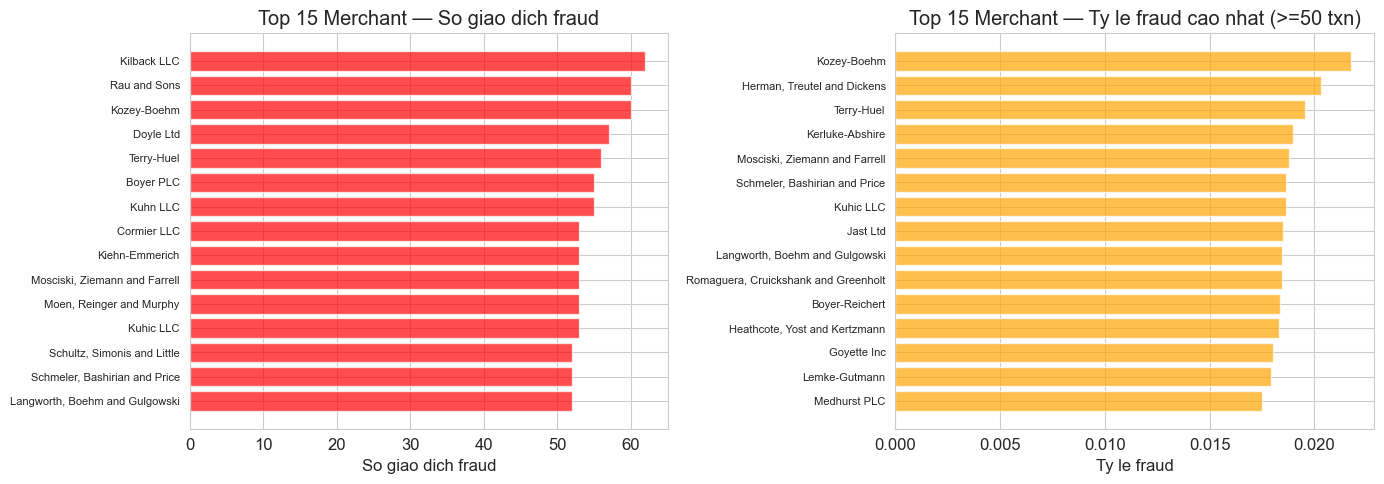

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_fraud_merchant_pd = merchant_stats.orderBy(F.desc("fraud_count")).limit(15).toPandas()
axes[0].barh(range(len(top_fraud_merchant_pd)),
             top_fraud_merchant_pd["fraud_count"], color="red", alpha=0.7)
axes[0].set_yticks(range(len(top_fraud_merchant_pd)))
axes[0].set_yticklabels([m.replace("fraud_", "") for m in top_fraud_merchant_pd["merchant"]], fontsize=8)
axes[0].set_xlabel("So giao dich fraud")
axes[0].set_title("Top 15 Merchant — So giao dich fraud")
axes[0].invert_yaxis()

high_rate = merchant_stats.join(merchant_deg, merchant_stats["merchant"] == merchant_deg["id"]) \
    .filter(F.col("inDegree") >= 50) \
    .orderBy(F.desc("fraud_rate")).limit(15).toPandas()
axes[1].barh(range(len(high_rate)),
             high_rate["fraud_rate"], color="orange", alpha=0.7)
axes[1].set_yticks(range(len(high_rate)))
axes[1].set_yticklabels([m.replace("fraud_", "") for m in high_rate["merchant"]], fontsize=8)
axes[1].set_xlabel("Ty le fraud")
axes[1].set_title("Top 15 Merchant — Ty le fraud cao nhat (>=50 txn)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## Trực quan hóa Graph

In [32]:
from pyvis.network import Network

top_fraud_merchants = fraud_edges_only.groupBy("dst") \
    .count().orderBy(F.desc("count")).limit(3) \
    .select("dst").toPandas()["dst"].tolist()

sample_edges = fraud_edges_only.filter(F.col("dst").isin(top_fraud_merchants)).toPandas()

net = Network(height="700px", width="100%", bgcolor="#ffffff", font_color="black", notebook=True)
net.barnes_hut(gravity=-3000, central_gravity=0.3, spring_length=200)

for m in top_fraud_merchants:
    label = m.replace("fraud_", "")
    fraud_count = len(sample_edges[sample_edges["dst"] == m])
    total_amt = sample_edges[sample_edges["dst"] == m]["amt"].sum()
    net.add_node(m,
        label=label,
        color="red",
        size=40,
        title=f"Merchant: {label}\nFraud transactions: {fraud_count}\nTotal fraud amount: ${total_amt:,.2f}",
        font={"size": 16, "color": "black", "bold": True}
    )

added_customers = set()
for _, row in sample_edges.iterrows():
    cid = row["src"]
    short_id = cid[:8] + "..."
    if cid not in added_customers:
        n_merchants = sample_edges[sample_edges["src"] == cid]["dst"].nunique()
        n_txn = len(sample_edges[sample_edges["src"] == cid])
        total = sample_edges[sample_edges["src"] == cid]["amt"].sum()
        net.add_node(cid,
            label=short_id,
            color="skyblue",
            size=15,
            title=f"Customer: {short_id}\nFull ID: {cid}\nFraud txn: {n_txn}\nMerchants: {n_merchants}\nTotal amount: ${total:,.2f}",
            font={"size": 8}
        )
        added_customers.add(cid)

    net.add_edge(cid, row["dst"],
        title=f"Amount: ${row['amt']:,.2f}",
        color="gray",
        width=1
    )

net.show("data/fraud_graph.html")
print(f"Graph: {len(added_customers)} customers, {len(top_fraud_merchants)} merchants, {len(sample_edges)} edges")

data/fraud_graph.html
Graph: 170 customers, 3 merchants, 182 edges


---
## Trực quan hóa mạng lưới fraud mở rộng
Hiển thị **20 merchant** có nhiều fraud nhất, chỉ hiện **customer có giao dịch fraud ở >= 2 merchant khác nhau**.

In [33]:
from pyvis.network import Network

# Top 10 merchant co nhieu fraud nhat
top_merchants = fraud_edges_only.groupBy("dst") \
    .count().orderBy(F.desc("count")).limit(10) \
    .select("dst").toPandas()["dst"].tolist()

# Loc cac edge fraud cua 10 merchant nay
edges_top = fraud_edges_only.filter(F.col("dst").isin(top_merchants))

# Tim customer co fraud >= 2 merchant khac nhau
multi_merchant_customers = edges_top.select("src", "dst").distinct() \
    .groupBy("src").agg(F.countDistinct("dst").alias("n_merchants")) \
    .filter(F.col("n_merchants") >= 2) \
    .select("src").toPandas()["src"].tolist()

# Chi giu edge cua nhung customer nay
edges_filtered = edges_top.filter(F.col("src").isin(multi_merchant_customers)).toPandas()

print(f"So merchant: {len(top_merchants)}")
print(f"So customer (fraud >= 2 merchant): {len(multi_merchant_customers)}")
print(f"So edge: {len(edges_filtered)}")

# Tao graph voi pyvis
net = Network(height="900px", width="100%", bgcolor="#ffffff", font_color="black", notebook=True)
net.barnes_hut(gravity=-5000, central_gravity=0.3, spring_length=250)

# Them merchant nodes
for m in top_merchants:
    label = m.replace("fraud_", "")
    m_edges = edges_filtered[edges_filtered["dst"] == m]
    fraud_count = len(m_edges)
    if fraud_count == 0:
        continue
    total_amt = m_edges["amt"].sum()
    size = 15 + min(fraud_count, 40)
    net.add_node(m,
        label=label,
        color="#e74c3c",
        size=size,
        title=f"Merchant: {label}\nFraud txn: {fraud_count}\nTotal fraud: ${total_amt:,.2f}",
        font={"size": 10, "color": "black"}
    )

# Them customer nodes
for cid in multi_merchant_customers:
    short_id = cid[:8] + "..."
    c_edges = edges_filtered[edges_filtered["src"] == cid]
    n_merch = c_edges["dst"].nunique()
    n_txn = len(c_edges)
    total = c_edges["amt"].sum()
    size = 8 + min(n_merch * 3, 20)
    net.add_node(cid,
        label=short_id,
        color="#3498db",
        size=size,
        title=f"Customer: {short_id}\nFull ID: {cid}\nFraud txn: {n_txn}\nMerchants: {n_merch}\nTotal: ${total:,.2f}",
        font={"size": 7}
    )

# Them edges
for _, row in edges_filtered.iterrows():
    net.add_edge(row["src"], row["dst"],
        title=f"Amount: ${row['amt']:,.2f}",
        color="#bdc3c7",
        width=1
    )

net.show("data/fraud_graph_extended.html")
print(f"\nDa luu: data/fraud_graph_extended.html")

So merchant: 10
So customer (fraud >= 2 merchant): 100
So edge: 227
data/fraud_graph_extended.html

Da luu: data/fraud_graph_extended.html


In [34]:
spark.stop()